# Diabetes Classification

A classifier comparison on the Pima diabetes dataset using the existing repo CSV and reproducible train/test splits.


#Set up

##Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import cross_val_score

# Classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

## Loading the dataset

Dataset is loaded from the project data folder.

In [2]:
# The dataset is stored in the project data folder, so no notebook download step is needed.


In [3]:
from pathlib import Path

data_path = Path('../data/diabetes.csv')
if not data_path.exists():
    data_path = Path('data/diabetes.csv')
if not data_path.exists():
    data_path = Path('projects/diabetes-classification/data/diabetes.csv')

df = pd.read_csv(data_path)
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


##Data analysis

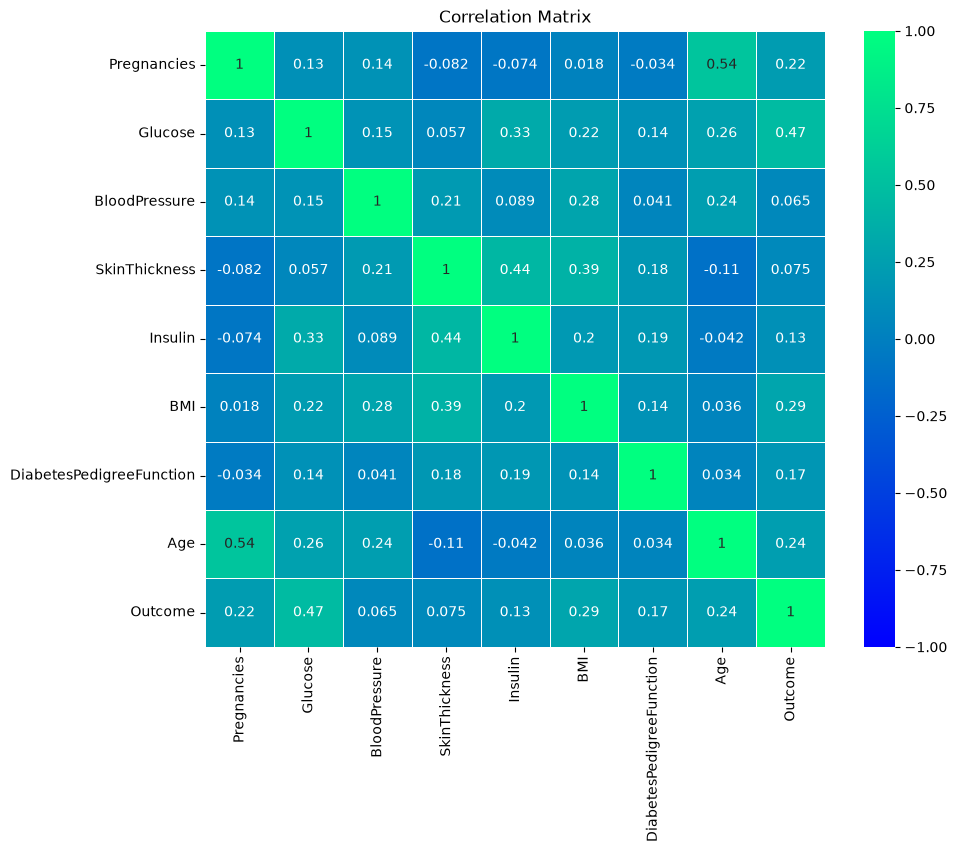

In [4]:
corr_matrix = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='winter', linewidths=0.5, vmin= -1, vmax= 1)
plt.title('Correlation Matrix')
plt.show()

In [5]:
selected_features = corr_matrix.sort_values(by='Outcome', ascending=False).index[0:6]
selected_features

Index(['Outcome', 'Glucose', 'BMI', 'Age', 'Pregnancies',
       'DiabetesPedigreeFunction'],
      dtype='object')

In [6]:
df = df[selected_features]

In [7]:
columns = df.columns
columns = list(columns)
new_cols = columns[1:] + [columns[0]]
print(new_cols)

['Glucose', 'BMI', 'Age', 'Pregnancies', 'DiabetesPedigreeFunction', 'Outcome']


In [8]:
df = df.reindex(columns=new_cols)

In [9]:
df

,Glucose,BMI,Age,Pregnancies,DiabetesPedigreeFunction,Outcome
0,148,33.6,50,6,0.627,1
1,85,26.6,31,1,0.351,0
2,183,23.3,32,8,0.672,1
3,89,28.1,21,1,0.167,0
4,137,43.1,33,0,2.288,1
...,...,...,...,...,...,...
763,101,32.9,63,10,0.171,0
764,122,36.8,27,2,0.340,0
765,121,26.2,30,5,0.245,0
766,126,30.1,47,1,0.349,1


###Features Distribution

<Axes: title={'center': 'Age'}, ylabel='Frequency'>

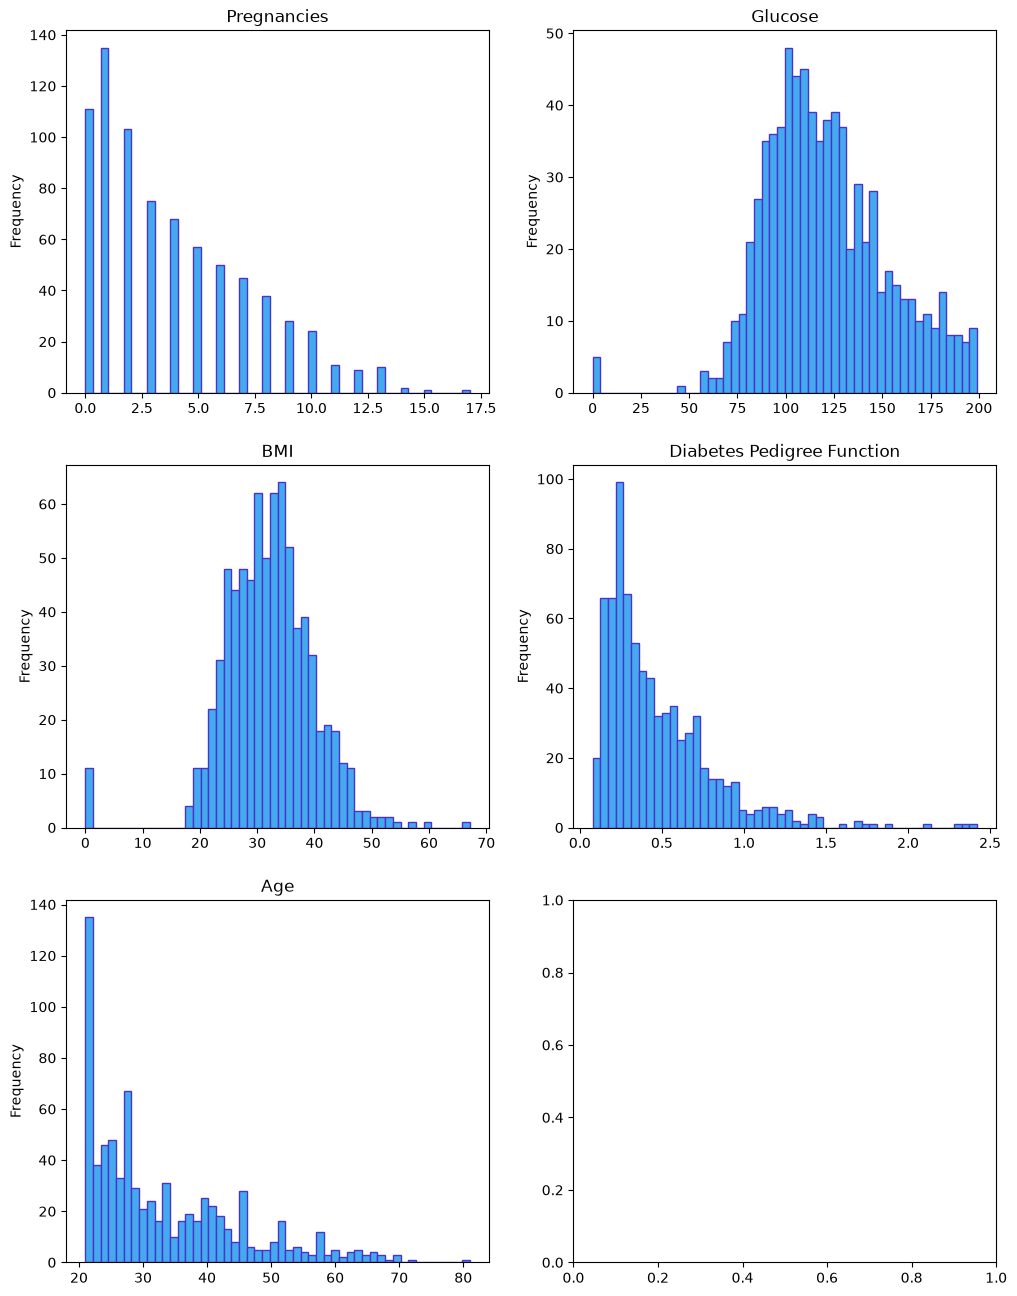

In [10]:
fig, axs = plt.subplots(3, 2, figsize=(12, 16))

# Plot the strongest numeric features used later in the models.
df['Pregnancies'].plot(kind='hist', bins=50, title='Pregnancies', ax=axs[0,0], color='#44aaee', edgecolor='#4a32cd')
df['Glucose'].plot(kind='hist', bins=50, title='Glucose', ax=axs[0,1], color='#44aaee', edgecolor='#4a32cd')
# df['BloodPressure'].plot(kind='hist', bins=50, title='Blood Pressure', ax=axs[1,0], color='#44aaee', edgecolor='#4a32cd')
# df['SkinThickness'].plot(kind='hist', bins=50, title='Skin Thickness', ax=axs[1,1], color='#44aaee', edgecolor='#4a32cd')
# df['Insulin'].plot(kind='hist', bins=50, title='Insulin', ax=axs[2,0], color='#44aaee', edgecolor='#4a32cd')
df['BMI'].plot(kind='hist', bins=50, title='BMI', ax=axs[1,0], color='#44aaee', edgecolor='#4a32cd')
df['DiabetesPedigreeFunction'].plot(kind='hist', bins=50, title='Diabetes Pedigree Function', ax=axs[1,1], color='#44aaee', edgecolor='#4a32cd')
df['Age'].plot(kind='hist', bins=50, title='Age', ax=axs[2,0], color='#44aaee', edgecolor='#4a32cd')

###Balance

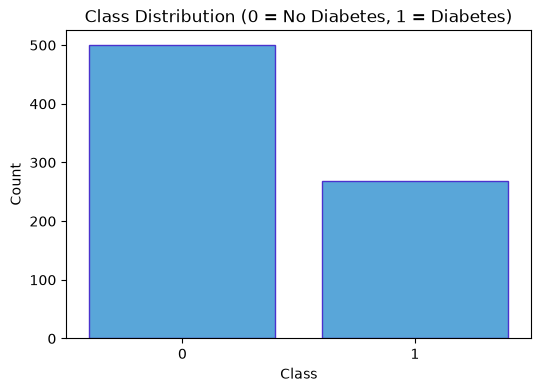

Outcome
0    500
1    268
Name: count, dtype: int64


In [11]:
# Class distribution plot
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df, color='#44aaee', edgecolor='#4a32cd')
plt.title('Class Distribution (0 = No Diabetes, 1 = Diabetes)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

print(df['Outcome'].value_counts())

#Classification

In [12]:
X = df.drop('Outcome', axis=1)
Y = df['Outcome']

Train-Test Split:

In [13]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

Standardize:

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##Decision Tree

Decision Tree Accuracy: 0.7012987012987013
              precision    recall  f1-score   support

           0       0.78      0.74      0.76        99
           1       0.57      0.64      0.60        55

    accuracy                           0.70       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.71      0.70      0.70       154



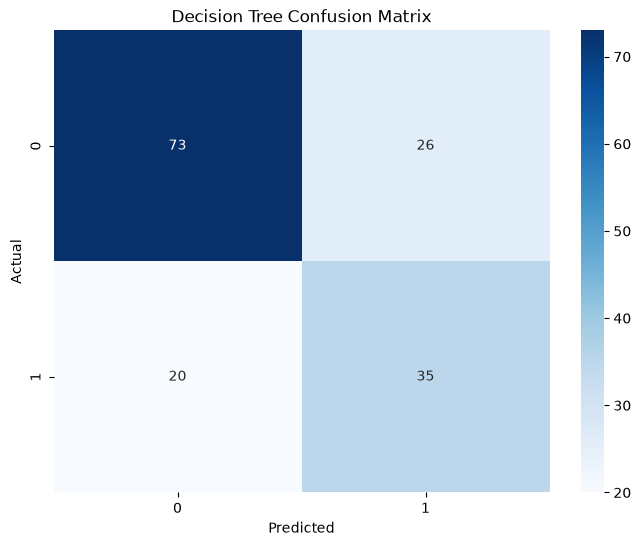

In [15]:
dt_model = DecisionTreeClassifier(criterion="gini",splitter = "best", max_depth = 4, min_samples_split = 100, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

##Naive Bayes

Naive Bayes Accuracy: 0.7532467532467533
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



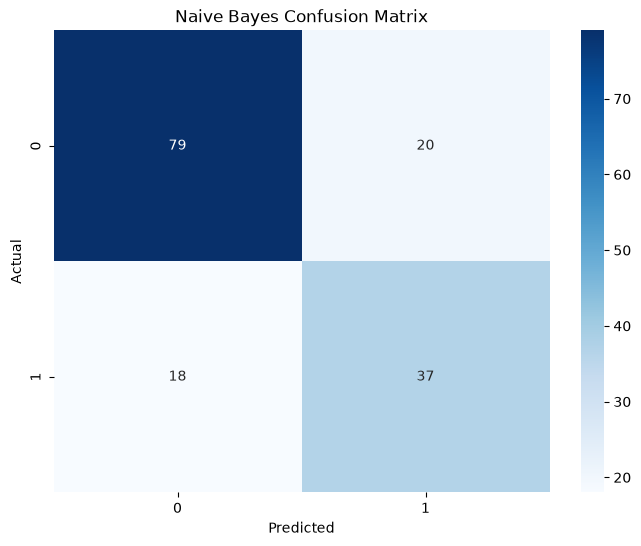

In [16]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))
cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

##SVM

SVM Accuracy: 0.7662337662337663
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        99
           1       0.68      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154



C:\Users\daniy\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


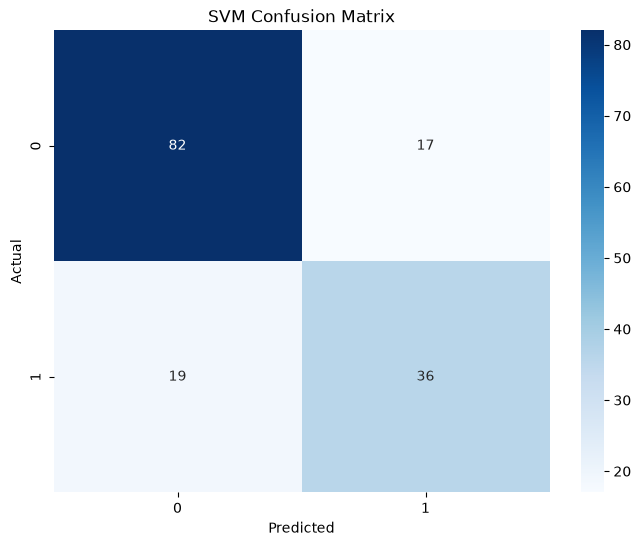

In [17]:
svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

##LDA

LDA Accuracy: 0.7532467532467533
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        99
           1       0.66      0.64      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



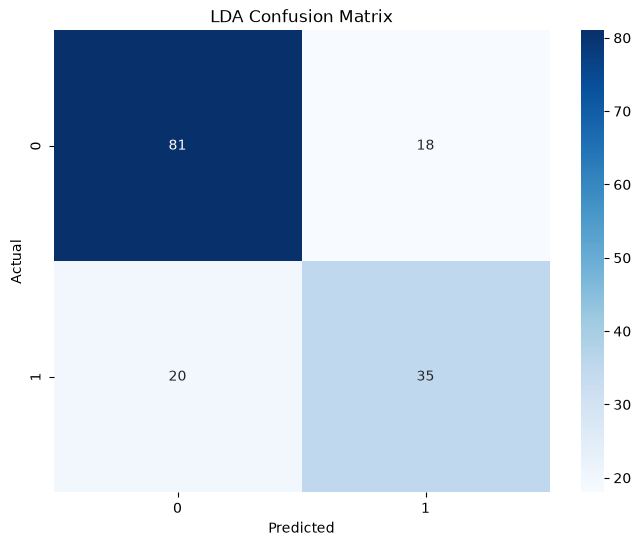

In [18]:
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)
y_pred_lda = lda_model.predict(X_test)
print("LDA Accuracy:", accuracy_score(y_test, y_pred_lda))
print(classification_report(y_test, y_pred_lda))
cm = confusion_matrix(y_test, y_pred_lda)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('LDA Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

##Random Forest

Random Forest Accuracy: 0.7597402597402597
              precision    recall  f1-score   support

           0       0.82      0.81      0.81        99
           1       0.66      0.67      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



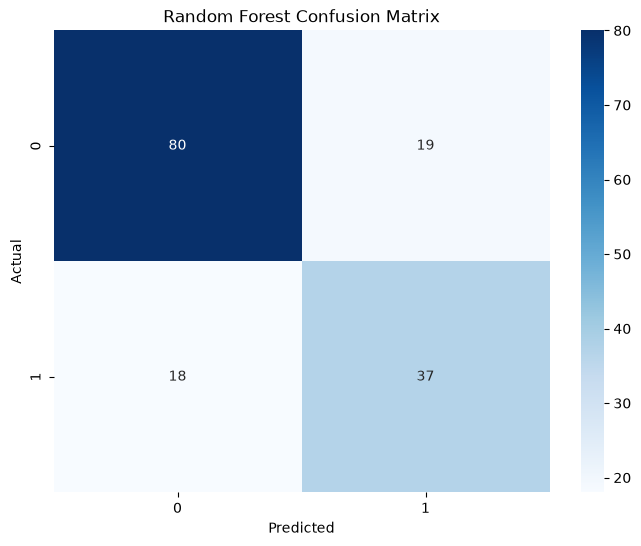

In [19]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## Logistic Regression

Logistic Regression Accuracy: 0.7532467532467533
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        99
           1       0.66      0.64      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



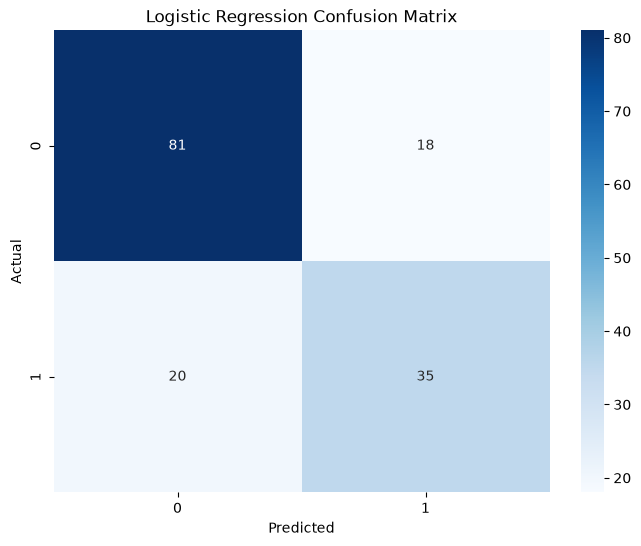

In [20]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Ensemble (Bagging) Classifier

Bagging (Ensemble) Accuracy: 0.7272727272727273
              precision    recall  f1-score   support

           0       0.78      0.81      0.79        99
           1       0.63      0.58      0.60        55

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.72      0.73      0.72       154



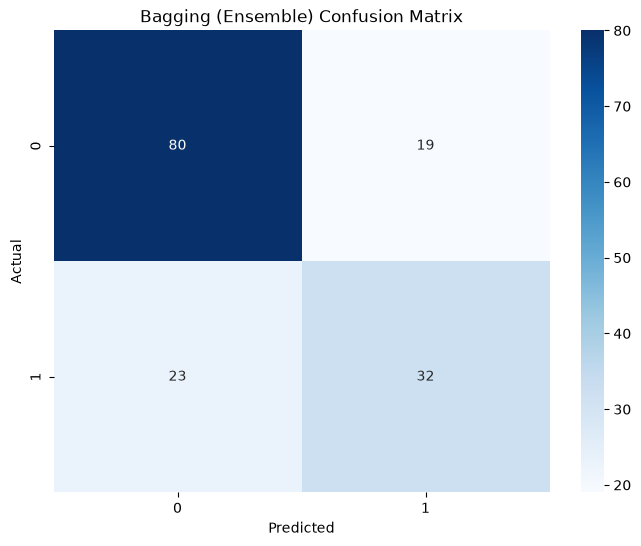

In [21]:
bagging_model = BaggingClassifier(random_state=42)
bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)
print("Bagging (Ensemble) Accuracy:", accuracy_score(y_test, y_pred_bagging))
print(classification_report(y_test, y_pred_bagging))
cm = confusion_matrix(y_test, y_pred_bagging)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Bagging (Ensemble) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#Comparison

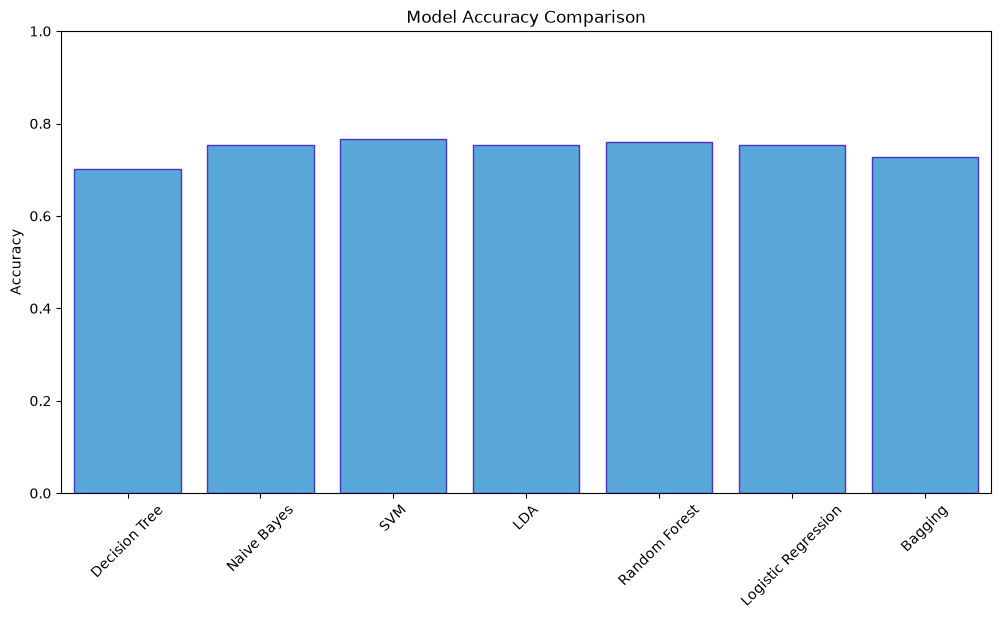

In [22]:
models = ['Decision Tree', 'Naive Bayes', 'SVM', 'LDA', 'Random Forest', 'Logistic Regression', 'Bagging']
accuracies = [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_lda),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_bagging)
]

plt.figure(figsize=(12,6))
sns.barplot(x=models, y=accuracies, color='#44aaee', edgecolor='#4a32cd')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()